# Identify Good Headliner Animation Window 

In this file, we are seeking out a spot in our data which can effectively communicate the idea of weather-related vehicle collisions in Connecticut. We want a window with precipitation and quite a few crashes

Loading weather CSVs …


/var/folders/lt/90cmmvp91vn9qgdwpxyyb6l40000gn/T/ipykernel_82025/1188557193.py:64: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df["time"] = pd.to_datetime(df["time"], infer_datetime_format=True)
/var/folders/lt/90cmmvp91vn9qgdwpxyyb6l40000gn/T/ipykernel_82025/1188557193.py:75: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("date", group_keys=False).apply(daily_delta)
/var/folders/lt/90cmmvp91vn9qgdwpxyyb6l40000gn/T/ipykernel_82025/1188557193.py:64: UserWarning: The argu

  Loaded 220 station files  |  86,782,080 hourly rows
  Hourly rows (2015+): 78,888
  Max single-hour mean precip: 63.0464 mm/hr
Loading crash data …


/var/folders/lt/90cmmvp91vn9qgdwpxyyb6l40000gn/T/ipykernel_82025/1188557193.py:114: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  pd.to_datetime(crash["Date Of Crash"].astype(str), infer_datetime_format=True)
/var/folders/lt/90cmmvp91vn9qgdwpxyyb6l40000gn/T/ipykernel_82025/1188557193.py:212: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  Crash range: 2013-07-15 → 2026-01-30

Scoring 120-hour windows (min 60.0 mm) …
  7068 qualifying windows found

── Top 10 windows (≥ 60 mm, ranked by crash count) ────────────────────
       window_start          window_end  precip_sum_mm  total_crashes
2019-12-09 06:00:00 2019-12-14 05:00:00      75.188920            512
2019-12-09 04:00:00 2019-12-14 03:00:00      70.287118            512
2019-12-09 03:00:00 2019-12-14 02:00:00      68.627135            512
2019-12-09 05:00:00 2019-12-14 04:00:00      72.378020            510
2019-12-09 02:00:00 2019-12-14 01:00:00      67.376983            508
2019-12-09 07:00:00 2019-12-14 06:00:00      78.993672            507
2019-12-09 01:00:00 2019-12-14 00:00:00      67.376983            504
2019-12-09 08:00:00 2019-12-14 07:00:00      83.900266            499
2019-12-09 00:00:00 2019-12-13 23:00:00      64.313433            498
2019-12-08 23:00:00 2019-12-13 22:00:00      63.476688            494

Full table → storm_finder_output/candidate_

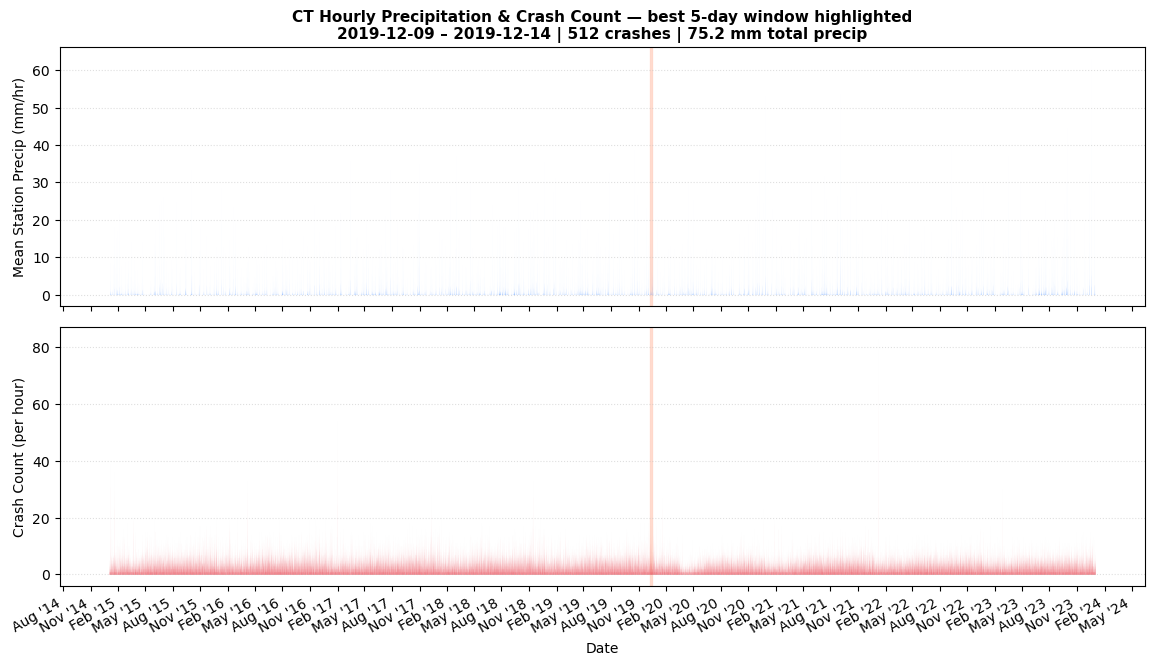


╔══════════════════════════════════════════════════════════════════════╗
║  RECOMMENDED 5-DAY WINDOW                                            ║
║  Start : 2019-12-09 06:00:00                                ║
║  End   : 2019-12-14 05:00:00                                ║
║  Crashes :    512   |   Total precip : 75.19 mm            ║
╚══════════════════════════════════════════════════════════════════════╝

→ Paste Start/End into ANIM_START / ANIM_END in ct_precip_crash_animation.py



In [4]:
"""
find_storm_window.py
────────────────────
Scans crash data + hourly weather data to find the best 5-day (120-hour) window
where:  (a) total precipitation across CT stations is ≥ 60 mm
            (ERA5 tp field is in METERS — converted to mm here), and
        (b) crash count over the window is maximised among qualifying windows.

Outputs a ranked table of candidate windows + a diagnostic plot.

Usage:
    python find_storm_window.py

Edit the PATHS section below to match your local directory layout.
"""

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ──────────────────────────────────────────────────────────────────────────────
# PATHS  ← edit these
# ──────────────────────────────────────────────────────────────────────────────
WEATHER_DIR = "/Volumes/JB_Fortress_L3/college_work/EEC/merged_csvs/"
CRASH_CSV   = (
    "/Users/jackbienvenuejr/Desktop/Desktop - jack-bienvenue/Spring2026Classes/"
    "STAT5605/STAT5605_AppliedStatII_Spring2026/course_project/data/"
    "clean_crash_data/crash_data_weather.csv"
)
OUT_DIR = "storm_finder_output"
# ──────────────────────────────────────────────────────────────────────────────

WINDOW_HRS    = 120     # 5-day window
MIN_PRECIP_MM = 60.0    # qualifying threshold in mm
M_TO_MM       = 1000.0  # ERA5 tp is in METERS → multiply to get mm

os.makedirs(OUT_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# 1.  LOAD & AGGREGATE WEATHER
#     ERA5 tp: cumulative within each UTC day, resets at midnight.
#     Hourly precip = within-day diff, clipped ≥ 0 (removes rounding artefacts).
#     Raw units: METERS → convert to mm by × 1000.
# ══════════════════════════════════════════════════════════════════════════════
print("Loading weather CSVs …")

weather_files = glob.glob(os.path.join(WEATHER_DIR, "*.csv"))
if not weather_files:
    raise FileNotFoundError(f"No CSVs found in {WEATHER_DIR}")

all_hourly = []

for fp in weather_files:
    try:
        df = pd.read_csv(fp)
        df.columns = df.columns.str.strip().str.lower()

        if "time" not in df.columns or "tp" not in df.columns:
            continue

        df["time"] = pd.to_datetime(df["time"], infer_datetime_format=True)
        df = df.sort_values("time").copy()
        df["date"] = df["time"].dt.date

        def daily_delta(grp):
            grp = grp.sort_values("time").copy()
            grp["precip_hr_m"] = grp["tp"].diff().clip(lower=0)
            # First entry of each day: raw tp value is the amount for that hour
            grp.loc[grp.index[0], "precip_hr_m"] = max(grp["tp"].iloc[0], 0)
            return grp

        df = df.groupby("date", group_keys=False).apply(daily_delta)

        # Convert METERS → MILLIMETERS
        df["precip_hr_mm"] = (df["precip_hr_m"] * M_TO_MM).clip(lower=0).fillna(0)

        all_hourly.append(df[["time", "precip_hr_mm"]])

    except Exception as e:
        print(f"  ⚠ Skipped {os.path.basename(fp)}: {e}")

if not all_hourly:
    raise RuntimeError("Could not parse any weather files.")

weather = pd.concat(all_hourly, ignore_index=True)
print(f"  Loaded {len(all_hourly)} station files  |  {len(weather):,} hourly rows")

# Mean precip across all stations per hour
hourly_precip = (
    weather.groupby("time")["precip_hr_mm"]
    .mean()
    .rename("mean_precip_mm")
    .reset_index()
    .sort_values("time")
)

# Restrict to crash-data era
hourly_precip = hourly_precip[hourly_precip["time"].dt.year >= 2015].copy()
print(f"  Hourly rows (2015+): {len(hourly_precip):,}")
print(f"  Max single-hour mean precip: {hourly_precip['mean_precip_mm'].max():.4f} mm/hr")

# ══════════════════════════════════════════════════════════════════════════════
# 2.  LOAD CRASH DATA
# ══════════════════════════════════════════════════════════════════════════════
print("Loading crash data …")

crash = pd.read_csv(CRASH_CSV)
crash.columns = crash.columns.str.strip()

crash["crash_dt"] = (
    pd.to_datetime(crash["Date Of Crash"].astype(str), infer_datetime_format=True)
    + pd.to_timedelta(crash["Hour of the Day"].astype(int), unit="h")
)

hourly_crashes = (
    crash.groupby("crash_dt")
    .size()
    .rename("crash_count")
    .reset_index()
    .rename(columns={"crash_dt": "time"})
)
print(f"  Crash range: {crash['crash_dt'].min().date()} → {crash['crash_dt'].max().date()}")

# ══════════════════════════════════════════════════════════════════════════════
# 3.  MERGE & ROLL
# ══════════════════════════════════════════════════════════════════════════════
merged = (
    hourly_precip
    .merge(hourly_crashes, on="time", how="left")
    .assign(crash_count=lambda d: d["crash_count"].fillna(0))
    .set_index("time")
    .sort_index()
)

roll_precip = merged["mean_precip_mm"].rolling(f"{WINDOW_HRS}h", min_periods=96).sum()
roll_crash  = merged["crash_count"].rolling(f"{WINDOW_HRS}h", min_periods=96).sum()

# ══════════════════════════════════════════════════════════════════════════════
# 4.  FILTER & RANK WINDOWS
# ══════════════════════════════════════════════════════════════════════════════
print(f"\nScoring {WINDOW_HRS}-hour windows (min {MIN_PRECIP_MM} mm) …")

qualifying = roll_precip[roll_precip >= MIN_PRECIP_MM]
print(f"  {len(qualifying)} qualifying windows found")

if len(qualifying) == 0:
    print("\n⚠  No windows met the 60 mm threshold.")
    print("  Top 10 raw precip windows (no threshold):")
    for ts, val in roll_precip.dropna().sort_values(ascending=False).head(10).items():
        print(f"    {ts}   {val:.2f} mm")
    raise SystemExit("Lower MIN_PRECIP_MM or extend date range and re-run.")

top = (
    roll_crash
    .reindex(qualifying.index)
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
    .rename(columns={"time": "window_end", "crash_count": "total_crashes"})
)
top["window_start"]  = top["window_end"] - pd.Timedelta(hours=WINDOW_HRS - 1)
top["precip_sum_mm"] = roll_precip.reindex(top["window_end"]).values
top["total_crashes"] = top["total_crashes"].astype(int)

print("\n── Top 10 windows (≥ 60 mm, ranked by crash count) ────────────────────")
print(
    top[["window_start", "window_end", "precip_sum_mm", "total_crashes"]]
    .head(10)
    .to_string(index=False)
)

top.to_csv(os.path.join(OUT_DIR, "candidate_windows.csv"), index=False)
print(f"\nFull table → {OUT_DIR}/candidate_windows.csv")

# ══════════════════════════════════════════════════════════════════════════════
# 5.  DIAGNOSTIC PLOT
# ══════════════════════════════════════════════════════════════════════════════
best_start = top["window_start"].iloc[0]
best_end   = top["window_end"].iloc[0]
best_n     = int(top["total_crashes"].iloc[0])
best_p     = top["precip_sum_mm"].iloc[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                facecolor="white",
                                gridspec_kw={"hspace": 0.08})

ax1.fill_between(merged.index, merged["mean_precip_mm"],
                 color="#3A86FF", alpha=0.6, linewidth=0)
ax1.axvspan(best_start, best_end, color="#FF6B35", alpha=0.18, zorder=0)
ax1.set_ylabel("Mean Station Precip (mm/hr)", fontsize=10)
ax1.set_title(
    f"CT Hourly Precipitation & Crash Count — best 5-day window highlighted\n"
    f"{best_start.date()} – {best_end.date()} | "
    f"{best_n:,} crashes | {best_p:.1f} mm total precip",
    fontsize=11, fontweight="bold"
)
ax1.yaxis.grid(True, linestyle=":", alpha=0.4)

ax2.fill_between(merged.index, merged["crash_count"],
                 color="#E63946", alpha=0.65, linewidth=0)
ax2.axvspan(best_start, best_end, color="#FF6B35", alpha=0.18, zorder=0)
ax2.set_ylabel("Crash Count (per hour)", fontsize=10)
ax2.set_xlabel("Date", fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.yaxis.grid(True, linestyle=":", alpha=0.4)

plt.xticks(rotation=30, ha="right")
fig.tight_layout()

out_fig = os.path.join(OUT_DIR, "storm_finder_overview.png")
fig.savefig(out_fig, dpi=150, bbox_inches="tight")
print(f"Diagnostic plot → {out_fig}")
plt.show()

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║  RECOMMENDED 5-DAY WINDOW                                            ║
║  Start : {best_start}                                ║
║  End   : {best_end}                                ║
║  Crashes : {best_n:>6,}   |   Total precip : {best_p:.2f} mm            ║
╚══════════════════════════════════════════════════════════════════════╝

→ Paste Start/End into ANIM_START / ANIM_END in ct_precip_crash_animation.py
""")